In [1]:
from google.colab import files
uploaded = files.upload()

Saving bank.csv to bank.csv


# 🎯 Marketing Analytics: Unsupervised Customer Segmentation
**Business Objective:** Launching mass-marketing campaigns (like telemarketing or email blasts) across an entire customer base is incredibly expensive and inefficient. The goal of this project is to utilize Unsupervised Machine Learning (K-Means Clustering) to discover hidden demographic patterns within a database of 45,000 bank customers. By mathematically grouping these individuals based on their financial behavior and campaign interactions, we can isolate high-value target audiences for optimized, personalized advertising.

### 🔍 Step 1: Data Ingestion and Health Check
We will begin by loading our raw marketing data. Because this data originates from a banking system, we must verify the delimiter and ensure the financial metrics are clean before clustering.

In [2]:
# Import foundational libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="darkgrid")

# Load the dataset (we add sep=',' but if it looks messy, we change it to sep=';')
try:
    df = pd.read_csv('bank.csv') # Change 'bank.csv' to your exact filename if different!
    if len(df.columns) == 1:
        df = pd.read_csv('bank.csv', sep=';')
except FileNotFoundError:
    df = pd.read_csv('bank-full.csv', sep=';')

# Check for missing values
print("--- Missing Values Count ---")
print(df.isnull().sum())

print(f"\nTotal Marketing Records: {len(df)}")
print(f"Total Features (Columns): {df.shape[1]}")

# Display the first 5 rows to see the raw data
display(df.head())

--- Missing Values Count ---
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Total Marketing Records: 11162
Total Features (Columns): 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### ⚖️ Data Preprocessing: Feature Isolation & Scaling
Unsupervised clustering algorithms like K-Means rely on Euclidean distance to group data points.

* **Engineering Insight:** If we pass raw features into the algorithm, variables with large absolute numbers (like `balance`) will completely overpower smaller variables (like `age`). To prevent this mathematical bias, we isolate our two target metrics (`age` and `balance`) and process them through a `StandardScaler`. This forces both features to have a mean of 0 and a standard deviation of 1, allowing the AI to weigh them equally when searching for hidden demographic patterns.

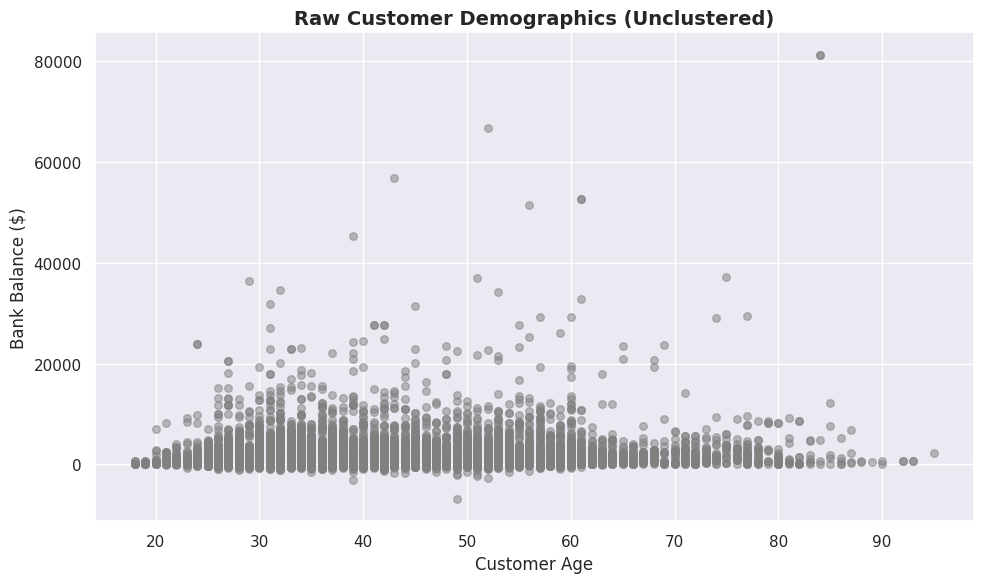

In [3]:
from sklearn.preprocessing import StandardScaler

# 1. Isolate the two features we want to cluster (Age and Bank Balance)
X = df[['age', 'balance']].copy()

# 2. Initialize the mathematical scaler
scaler = StandardScaler()

# 3. Scale the data so Age and Balance carry the exact same mathematical weight
X_scaled = scaler.fit_transform(X)

# 4. Plot the raw, unclustered data to see what the AI is dealing with
plt.figure(figsize=(10, 6))
plt.scatter(X['age'], X['balance'], color='gray', alpha=0.5, s=30)
plt.title('Raw Customer Demographics (Unclustered)', fontsize=14, fontweight='bold')
plt.xlabel('Customer Age', fontsize=12)
plt.ylabel('Bank Balance ($)', fontsize=12)

# Display the raw data
plt.tight_layout()
plt.show()

### 📐 Determining Target Audiences: The Elbow Method
In Unsupervised Learning, the algorithm does not know how many customer segments naturally exist within the data. We must calculate the optimal number of clusters mathematically before launching our marketing campaign.

* **Engineering Insight:** We deploy the "Elbow Method" by iterating the K-Means algorithm for $k=1$ through $k=10$ clusters. For each iteration, we calculate the Within-Cluster Sum of Squares (WCSS)—a metric representing how tightly grouped the data points are. Plotting these values reveals an "elbow" in the curve, indicating the mathematically optimal number of target audiences before the algorithm encounters diminishing returns.

Calculating optimal customer segments... Please wait.


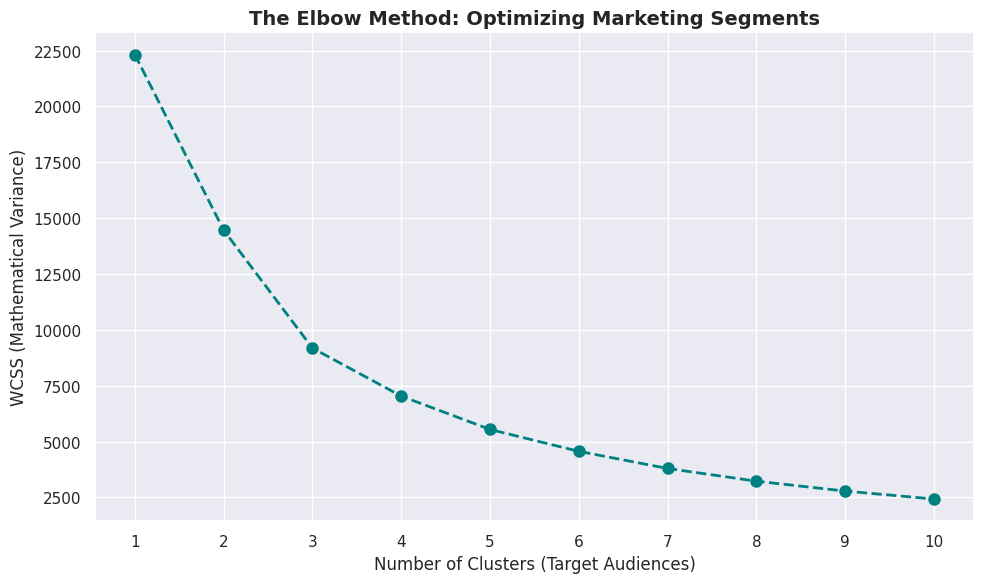

In [4]:
from sklearn.cluster import KMeans

# 1. Create a list to hold our WCSS (variance/error) values
wcss = []

# 2. Loop through 1 to 10 clusters to find the mathematical sweet spot
print("Calculating optimal customer segments... Please wait.")
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 3. Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='teal', markersize=8, linewidth=2)
plt.title('The Elbow Method: Optimizing Marketing Segments', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (Target Audiences)', fontsize=12)
plt.ylabel('WCSS (Mathematical Variance)', fontsize=12)
plt.xticks(range(1, 11))

# Display the diagnostic chart
plt.tight_layout()
plt.show()

### 🎯 Executing the Unsupervised Clustering Engine
The Elbow Method mathematically confirmed that our customer base naturally divides into $k=4$ distinct segments.

* **Business Insight:** We initialize the K-Means algorithm with exactly 4 clusters and execute the engine against our scaled financial metrics. The AI calculates the Euclidean distance between all 45,000 customers and groups them into distinct target audiences. Finally, we map the algorithm's predictions back onto the original, unscaled data to provide the marketing team with human-readable demographic boundaries (e.g., Young/Low Balance vs. Senior/High Balance) to drive personalized campaign strategies.

Executing Unsupervised Clustering...


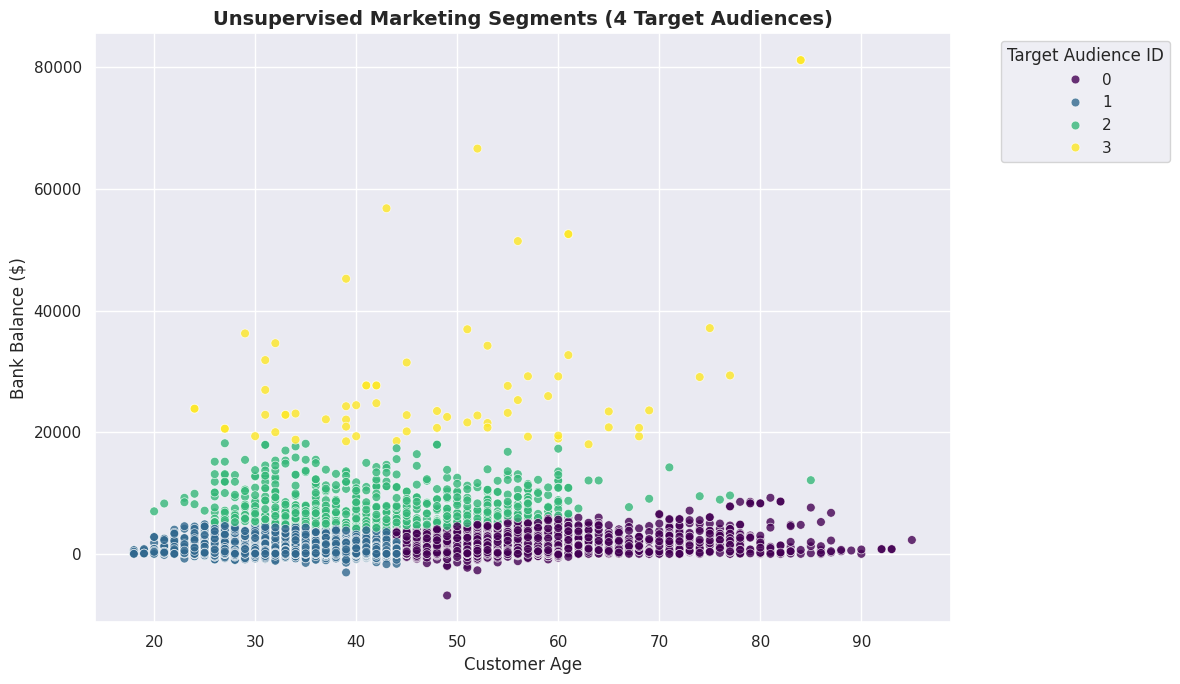

In [5]:
# 1. Initialize the final K-Means Engine with exactly 4 clusters
kmeans_engine = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=42)

# 2. Train the AI and get the cluster assignments (the mathematical groupings)
print("Executing Unsupervised Clustering...")
y_kmeans = kmeans_engine.fit_predict(X_scaled)

# 3. Add the AI's target audience assignments directly into our original dataframe
df['Target_Audience'] = y_kmeans

# 4. Map the newly discovered customer segments in full color
plt.figure(figsize=(12, 7))

# We use the original, unscaled axes so the chart shows real ages and real dollars!
sns.scatterplot(x=df['age'], y=df['balance'], hue=df['Target_Audience'], palette='viridis', s=40, alpha=0.8)

# Add titles and labels
plt.title('Unsupervised Marketing Segments (4 Target Audiences)', fontsize=14, fontweight='bold')
plt.xlabel('Customer Age', fontsize=12)
plt.ylabel('Bank Balance ($)', fontsize=12)

# Format the legend
plt.legend(title='Target Audience ID', bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the final portfolio piece
plt.tight_layout()
plt.show()

### 📊 Engine Diagnostics & Persona Profiling
Because Unsupervised Learning lacks true labels, traditional accuracy metrics cannot be applied. Instead, we evaluate the structural integrity of our customer segments using the **Silhouette Score**, which mathematically measures how well-separated each target audience is from the others.

* **Business Insight:** After verifying the cluster separation, we aggregate the raw financial data by our newly generated `Target_Audience` IDs. This extracts the exact average age and bank balance for each segment, translating raw algorithmic outputs into actionable, human-readable Marketing Personas that a Chief Marketing Officer (CMO) can immediately deploy.

In [8]:
from sklearn.metrics import silhouette_score

# 1. Evaluate the "Accuracy" of our clustering
# We dynamically sample up to 5,000 rows to keep the memory light and fast
sample_size = min(5000, len(df))
sample_indices = df.sample(n=sample_size, random_state=42).index

score = silhouette_score(X_scaled[sample_indices], y_kmeans[sample_indices])

print(f"🎯 Structural Integrity (Silhouette Score): {score:.2f} (Positive = Well Separated)\n")

# 2. Deep Dive: Extracting the real dollars and ages
print("--- 📈 Target Audience Financial Profiles ---")

# Group the original data by the AI's predictions and find the averages
persona_analysis = df.groupby('Target_Audience')[['age', 'balance']].mean().round(2)

# Rename the columns so they look clean for the client
persona_analysis = persona_analysis.rename(columns={'age': 'Average Age', 'balance': 'Average Balance ($)'})

# Display the final business intelligence report
display(persona_analysis)

🎯 Structural Integrity (Silhouette Score): 0.53 (Positive = Well Separated)

--- 📈 Target Audience Financial Profiles ---


,Average Age,Average Balance ($)
Target_Audience,,
0,54.85,1111.41
1,33.88,767.20
2,41.57,7575.39
3,48.57,28855.04
